1. Título

2. Objetivo

3. Importação das bibliotecas

4. Reutilização da preparação da Fase 1
   (copiar somente as células necessárias)

5. Validação dos dados

6. Definição do espaço de busca

7. Criar indivíduo

8. Criar população

9. Construir modelo

10. Fitness

11. Seleção

12. Crossover

13. Mutação

14. Elitismo

15. Algoritmo Genético

16. Executar AG para cada modelo

17. Experimento 1

18. Experimento 2

19. Experimento 3

20. Comparação dos resultados

21. Conclusão

# Tech Challenge – Fase 2

## Otimização de Hiperparâmetros utilizando Algoritmos Genéticos

### Objetivo

Este notebook tem como objetivo otimizar os hiperparâmetros dos modelos de Machine Learning desenvolvidos na Fase 1 do Tech Challenge utilizando um Algoritmo Genético.

A preparação dos dados será reutilizada integralmente da Fase 1, garantindo que qualquer melhoria obtida seja resultado exclusivamente da otimização dos hiperparâmetros.

Os modelos avaliados serão:

- Regressão Logística
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

Ao final, cada modelo será comparado em sua versão:

- **Modelo Original (Fase 1)**
- **Modelo Otimizado (Fase 2)**

As comparações utilizarão as métricas:

- Accuracy
- Precision
- Recall
- F1-Score

In [5]:
# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Reutilização da Preparação dos Dados (Fase 1)

Nesta etapa serão reutilizadas apenas as células da Fase 1 responsáveis pelo carregamento e preparação dos dados.

**Serão reutilizadas:**

- Download e carregamento dos datasets;
- Concatenação dos datasets;
- Remoção de duplicidades;
- Tratamento dos valores inconsistentes;
- Imputação dos valores ausentes;
- Tratamento dos outliers;
- Criação do DataFrame final (`df_clean`);
- Definição de `X` e `y`;
- Divisão em treino e teste (`train_test_split`).

**Não serão reutilizadas:**

- Análises exploratórias;
- Gráficos;
- Estatísticas descritivas;
- Treinamento dos modelos;
- Avaliação dos modelos.

In [6]:
import kagglehub
import os

datasets_names = [
    "hasibur013/diabetes-dataset",
    "anupriyaparakale/diabetes-detection",
    "karanshah1910/diabetes-prediction",
    "ehsankhani/diabetes-health-indicators-dataset",
    "nanditapore/healthcare-diabetes",
    "uciml/pima-indians-diabetes-database"
]

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'IMC', 'DPF', 'Age', 'Outcome']

# Cria uma lista com todos datasets
datasets = [];
for i in range(len(datasets_names)):
  path = kagglehub.dataset_download(datasets_names[i])
  filename = os.listdir(path)[0]
  filepath = os.path.join(path, filename)
  print(f"Attempting to read: {filepath}")
  datasets.append(pd.read_csv(filepath))
  print(f"{datasets_names[i]} has {datasets[-1].shape} (rows, columns) and columns: {datasets[-1].columns.tolist()}\n")




100%|██████████| 8.93k/8.93k [00:00<00:00, 3.89MB/s]

Extracting files...
Attempting to read: /root/.cache/kagglehub/datasets/hasibur013/diabetes-dataset/versions/1/diabetes_dataset.csv
hasibur013/diabetes-dataset has (768, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']



100%|██████████| 8.93k/8.93k [00:00<00:00, 6.15MB/s]

Extracting files...
Attempting to read: /root/.cache/kagglehub/datasets/anupriyaparakale/diabetes-detection/versions/1/health diabetes.csv
anupriyaparakale/diabetes-detection has (774, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']



100%|██████████| 8.91k/8.91k [00:00<00:00, 17.1MB/s]

...

Extracting files...
Attempting to read: /root/.cache/kagglehub/datasets/ehsankhani/diabetes-health-indicators-dataset/versions/1/Dataset.csv
ehsankhani/diabetes-health-indicators-dataset has (768, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age', 'Outcome']



100%|██████████| 26.7k/26.7k [00:00<00:00, 3.23MB/s]

Extracting files...
Attempting to read: /root/.cache/kagglehub/datasets/nanditapore/healthcare-diabetes/versions/1/Healthcare-Diabetes.csv
nanditapore/healthcare-diabetes has (2768, 10) (rows, columns) and columns: ['Id', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']



100%|██████████| 8.91k/8.91k [00:00<00:00, 13.8MB/s]

Extracting files...
Attempting to read: /root/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1/diabetes.csv
uciml/pima-indians-diabetes-database has (768, 9) (rows, columns) and columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']



In [7]:
# Verifica se os datasets são iguais
repeated_datasets = []
for i in range(len(datasets)):
  for j in range(i+1, len(datasets)):
    # Normaliza nomes de coluna para permitir comparação mesmo com pequenas diferenças de nome
    df_i_normalized = datasets[i].rename(columns={'DiabetesPedigreeFunction': 'DPF'})
    df_j_normalized = datasets[j].rename(columns={'DiabetesPedigreeFunction': 'DPF'})

    # Garante que ambos os dataframes tenham as mesmas colunas na mesma ordem para comparação exata
    common_cols = list(set(df_i_normalized.columns) & set(df_j_normalized.columns))
    df_i_common = df_i_normalized[common_cols].sort_index(axis=1)
    df_j_common = df_j_normalized[common_cols].sort_index(axis=1)

    if (df_i_common.equals(df_j_common)):
      repeated_datasets.append(j) # Adiciona o índice do dataset repetido
      print(f"Dataset {datasets_names[i]} e {datasets_names[j]} são iguais (ou muito semelhantes nas colunas comuns).")


# Remove os datasets repetidos da lista de datasets
unique_datasets = [datasets[i] for i in range(len(datasets)) if i not in repeated_datasets]

# Agora, concatena os datasets únicos
# Primeiro, padronize os nomes das colunas e a ordem, se necessário, antes da concatenação.

processed_unique_datasets = []
for df_item in unique_datasets:
    # Renomeia 'DiabetesPedigreeFunction' para 'DPF' se existir
    if 'DiabetesPedigreeFunction' in df_item.columns:
        df_item = df_item.rename(columns={'DiabetesPedigreeFunction': 'DPF'})
    if 'BMI' in df_item.columns:
        df_item = df_item.rename(columns={'BMI': 'IMC'})

    # Reindexa o DataFrame para ter as colunas desejadas na ordem correta.
    # Colunas que não existirem em df_item serão preenchidas com NaN.
    # Colunas em df_item que não estiverem na lista `columns` serão removidas.
    df_item = df_item.reindex(columns=columns)
    processed_unique_datasets.append(df_item)

# Concatena os datasets processados
df = pd.concat(processed_unique_datasets, ignore_index=True)

print("\nDatasets únicos combinados:")
for i in range(len(datasets)):
  if i not in repeated_datasets:
    print(f"    {datasets_names[i]}")

print(f"\nShape do DataFrame combinado: {df.shape}")

print("\nPrimeiras 5 linhas do DataFrame combinado:")
display(df.head())

print("\nInformações do DataFrame combinado:")
df.info()

Dataset hasibur013/diabetes-dataset e karanshah1910/diabetes-prediction são iguais (ou muito semelhantes nas colunas comuns).
Dataset hasibur013/diabetes-dataset e ehsankhani/diabetes-health-indicators-dataset são iguais (ou muito semelhantes nas colunas comuns).
Dataset hasibur013/diabetes-dataset e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).
Dataset karanshah1910/diabetes-prediction e ehsankhani/diabetes-health-indicators-dataset são iguais (ou muito semelhantes nas colunas comuns).
Dataset karanshah1910/diabetes-prediction e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).
Dataset ehsankhani/diabetes-health-indicators-dataset e uciml/pima-indians-diabetes-database são iguais (ou muito semelhantes nas colunas comuns).

Datasets únicos combinados:
    hasibur013/diabetes-dataset
    anupriyaparakale/diabetes-detection
    nanditapore/healthcare-diabetes

Shape do DataFrame combinado: (4310, 9)

Pr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Informações do DataFrame combinado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    4310 non-null   int64  
 1   Glucose        4310 non-null   int64  
 2   BloodPressure  4310 non-null   int64  
 3   SkinThickness  4310 non-null   int64  
 4   Insulin        4310 non-null   int64  
 5   IMC            4310 non-null   float64
 6   DPF            4310 non-null   float64
 7   Age            4310 non-null   int64  
 8   Outcome        4310 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 303.2 KB


In [8]:
print(f"Número de linhas antes da remoção de duplicatas: {df.shape[0]}")

duplicated_rows_count = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicated_rows_count}")

if duplicated_rows_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicatas removidas. Número de linhas após remoção: {df.shape[0]}")
else:
    print("Nenhuma duplicata encontrada.")

Número de linhas antes da remoção de duplicatas: 4310
Número de linhas duplicadas: 3532
Duplicatas removidas. Número de linhas após remoção: 778


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer

# Substituindo zeros por NaN nas colunas onde o zero é clinicamente impossível
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'IMC']

print('--- Análise de Valores Zero (Possíveis Missing Values) ---')
for col in cols_to_fix:
    zeros_count = (df[col] == 0).sum()
    percentage = (zeros_count / len(df)) * 100
    print(f'{col}: {zeros_count} zeros ({percentage:.2f}%)')

# Criando uma cópia para preservar os dados originais se necessário
df_clean = df.copy()

for col in cols_to_fix:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\n\n--- Contagem de valores nulos após substituição dos zeros por NaN ---")
display(df_clean[cols_to_fix].isnull().sum())

# Substituindos os valores NaN pela mediana
imputer = SimpleImputer(strategy='median')
imputer.fit_transform(df_clean[cols_to_fix])
df_clean[cols_to_fix] = imputer.transform(df_clean[cols_to_fix])

print("\n\n--- Contagem de valores nulos após substituição do NaN pelas medianas ---")
display(df_clean[cols_to_fix].isnull().sum())

--- Análise de Valores Zero (Possíveis Missing Values) ---
Glucose: 5 zeros (0.64%)
BloodPressure: 36 zeros (4.63%)
SkinThickness: 229 zeros (29.43%)
Insulin: 377 zeros (48.46%)
IMC: 11 zeros (1.41%)


--- Contagem de valores nulos após substituição dos zeros por NaN ---


,0
Glucose,5
BloodPressure,36
SkinThickness,229
Insulin,377
IMC,11




--- Contagem de valores nulos após substituição do NaN pelas medianas ---


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
IMC,0


In [10]:
# Capping (Winsorization) dos Outliers usando o 99º percentil
# para Insulin e SkinThickness

print("\nEstatísticas descritivas antes do capping:")
display(df_clean[['Insulin', 'SkinThickness']].describe())

for col in ['Insulin', 'SkinThickness']:
    upper_bound = df_clean[col].quantile(0.99)
    df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

print("\nEstatísticas descritivas após o capping:")
display(df_clean[['Insulin', 'SkinThickness']].describe())


Estatísticas descritivas antes do capping:


,Insulin,SkinThickness
count,778.000000,778.000000
mean,141.444730,29.299486
std,85.978838,9.307780
min,14.000000,7.000000
25%,122.750000,25.000000
50%,126.000000,29.000000
75%,130.000000,32.000000
max,846.000000,110.000000



Estatísticas descritivas após o capping:


,Insulin,SkinThickness
count,778.00000,778.000000
mean,140.23419,29.125553
std,78.89412,8.437728
min,14.00000,7.000000
25%,122.75000,25.000000
50%,126.00000,29.000000
75%,130.00000,32.000000
max,516.90000,52.460000


In [11]:
# A seguir, iremos separar todas as colunas na lista de ‘recursos’ para uma variável ‘X’ e a variável ‘destino’ para ‘y’.

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X.head()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,IMC,DPF,Age
0,6,148.0,72.0,35.0,126.0,33.6,0.627,50
1,1,85.0,66.0,29.0,126.0,26.6,0.351,31
2,8,183.0,64.0,29.0,126.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


Finalmente vamos treinar o modelo de dados

In [12]:
from sklearn.model_selection import train_test_split

# test_size = guardar 20% dos valores
# a saída do método é constante, a ordenação muda de acordo com random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"\n\nProporção de diagnósticos positivos e negativos para treino:\n{y_train.value_counts(normalize=True).map('{:.2%}'.format)}")

print(f"\n\nProporção de diagnósticos positivos e negativos para teste:\n{y_test.value_counts(normalize=True).map('{:.2%}'.format)}")



Proporção de diagnósticos positivos e negativos para treino:
Outcome
0    63.67%
1    36.33%
Name: proportion, dtype: object


Proporção de diagnósticos positivos e negativos para teste:
Outcome
0    70.51%
1    29.49%
Name: proportion, dtype: object


De acordo com o material de estudo a Regressão Logística é recomendável para predizer targets booleanos, porém iremos testar outros modelos para comparar a eficiência

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

modelos = {
    "Regressão Logistica": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

resultados = []

for nome, modelo in modelos.items():

    pipeline = Pipeline([
        ('scaler', StandardScaler()), # padronizando as escalas dos dados
        ('model', modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Acuracia": accuracy_score(y_test, y_pred), # Não é aconselhável utilizar como métrica, mas inseri para compararmos
        "Precisao": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred), # Quantos dos casos realmente positivos o modelo conseguiu identificar corretamente
        "F1": f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by="F1", ascending=False)

,Modelo,Acuracia,Precisao,Recall,F1
2,SVM,0.788462,0.632653,0.673913,0.652632
1,Random Forest,0.769231,0.589286,0.717391,0.647059
0,Regressão Logistica,0.743590,0.557692,0.630435,0.591837
3,KNN,0.698718,0.491803,0.652174,0.560748


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Configurar Stratified K-Fold Cross-Validation
# Garante que cada fold tenha a mesma proporção de classes que o dataset original
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_resultados = []

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

    # Executar validação cruzada para diferentes métricas
    accuracy_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
    precision_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='precision', n_jobs=-1)
    recall_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='recall', n_jobs=-1)
    f1_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='f1', n_jobs=-1)

    cv_resultados.append({
        "Modelo": nome,
        "Acuracia_CV": accuracy_scores.mean(),
        "Precisao_CV": precision_scores.mean(),
        "Recall_CV": recall_scores.mean(),
        "F1_CV": f1_scores.mean()
    })

df_cv_resultados = pd.DataFrame(cv_resultados)
print("\nResultados da Validação Cruzada (Média dos Scores):")
display(df_cv_resultados.sort_values(by="F1_CV", ascending=False))


Resultados da Validação Cruzada (Média dos Scores):


,Modelo,Acuracia_CV,Precisao_CV,Recall_CV,F1_CV
1,Random Forest,0.764806,0.684350,0.588215,0.633421
3,KNN,0.742961,0.648753,0.584242,0.613506
2,SVM,0.762217,0.715848,0.540000,0.612181
0,Regressão Logistica,0.758371,0.704353,0.540067,0.608179



Modelo: Regressão Logistica


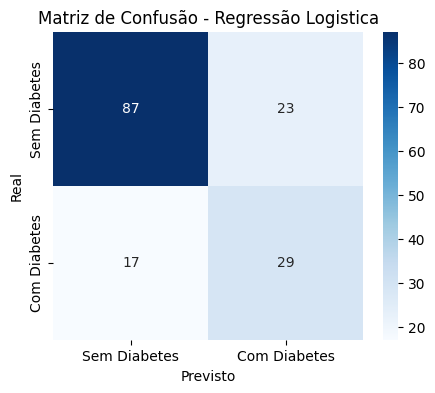


Modelo: Random Forest


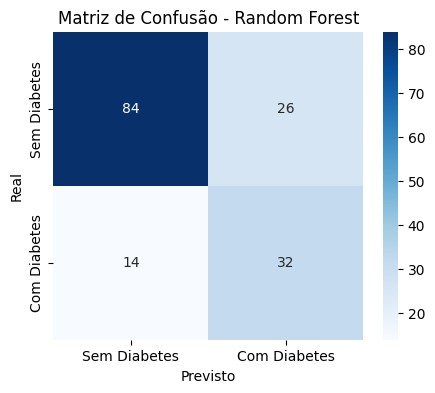


Modelo: SVM


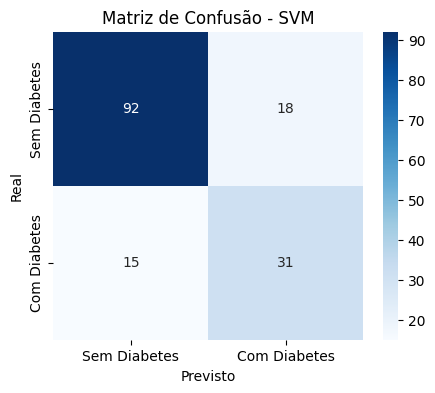


Modelo: KNN


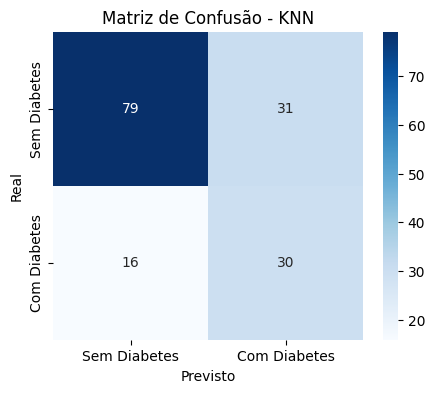

In [15]:
from sklearn.metrics import confusion_matrix

for nome, modelo in modelos.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\nModelo: {nome}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Sem Diabetes', 'Com Diabetes'],
        yticklabels=['Sem Diabetes', 'Com Diabetes']
    )
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

A PARTIR DAQUI INICIA-SE A FASE 2

In [16]:
# ==========================================================
# VALIDAÇÃO DA PREPARAÇÃO DOS DADOS
# ==========================================================

print("Preparação dos dados reutilizada com sucesso!\n")

print(f"Dataset final: {df_clean.shape}")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Preparação dos dados reutilizada com sucesso!

Dataset final: (778, 9)
X_train: (622, 8)
X_test : (156, 8)
y_train: (622,)
y_test : (156,)


# Algoritmo Genético

Nesta seção será implementado o Algoritmo Genético responsável por otimizar os hiperparâmetros dos modelos desenvolvidos na Fase 1.

A implementação será composta pelas seguintes etapas:

1. Definição do espaço de busca;
2. Geração da população inicial;
3. Avaliação (Fitness);
4. Seleção;
5. Crossover;
6. Mutação;
7. Elitismo;
8. Evolução da população.

In [17]:
# ==========================================================
# CONFIGURAÇÃO DO ALGORITMO GENÉTICO
# ==========================================================

AG_CONFIG = {
    "population_size": 20,
    "generations": 5,
    "mutation_rate": 0.10,
    "elite_size": 2,
    "tournament_size": 3
}

print("Configuração do Algoritmo Genético")

for parametro, valor in AG_CONFIG.items():
    print(f"{parametro}:{valor}")

Configuração do Algoritmo Genético
population_size:20
generations:5
mutation_rate:0.1
elite_size:2
tournament_size:3


## Fluxo do Algoritmo Genético

Nesta etapa será implementado um Algoritmo Genético para otimizar os hiperparâmetros dos modelos de Machine Learning desenvolvidos na Fase 1.

Cada solução candidata será representada por um **indivíduo**, composto por um conjunto de **genes**, onde cada gene representa um hiperparâmetro do modelo.

O processo evolutivo seguirá o fluxo abaixo:

```
Representação dos indivíduos
            |
    População Inicial
            │
   Avaliação (Fitness)
            │
         Seleção
            │
        Crossover
            │
         Mutação
            │
        Elitismo
            │
       Nova Geração
            │
 Melhor Conjunto de Hiperparâmetros
```

Ao final das gerações, o melhor indivíduo encontrado será utilizado para treinar novamente o modelo, permitindo comparar o **Modelo Original (Fase 1)** com o **Modelo Otimizado (Fase 2)** utilizando as métricas de Accuracy, Precision, Recall e F1-Score.

## Representação Genética

Antes de iniciar a evolução da população é necessário definir como cada indivíduo será representado.

Neste projeto, cada indivíduo corresponde a um conjunto de hiperparâmetros de um modelo de Machine Learning.

Cada hiperparâmetro representa um **gene**, enquanto o conjunto completo de genes representa um **cromossomo**.

O espaço de busca definido a seguir estabelece quais hiperparâmetros poderão ser modificados pelo Algoritmo Genético durante o processo de otimização.

In [18]:
# ==========================================================
# ESPAÇO DE BUSCA DOS HIPERPARÂMETROS
# ==========================================================

search_space = {

    "LogisticRegression": {
        "C": (0.1, 10.0),
        "solver": ["lbfgs", "liblinear"],
        "max_iter": (100, 500)
    },

    "RandomForest": {
        "n_estimators": (50, 200),
        "max_depth": (3, 15),
        "min_samples_split": (2, 10)
    },

    # "SVM": {
    #     "C": (0.1, 10.0),
    #     "kernel": ["linear", "rbf"]
    # },

    "KNN": {
        "n_neighbors": (3, 15),
        "weights": ["uniform", "distance"]
    }

}

In [19]:
# ==========================================================
# VISUALIZAÇÃO DO ESPAÇO DE BUSCA
# ==========================================================

for modelo, parametros in search_space.items():

    print(f"\n{'=' * 50}")
    print(f"Modelo: {modelo}")
    print(f"{'=' * 50}")

    for hiperparametro, dominio in parametros.items():
        print(f"{hiperparametro:<20} -> {dominio}")


Modelo: LogisticRegression
C                    -> (0.1, 10.0)
solver               -> ['lbfgs', 'liblinear']
max_iter             -> (100, 500)

Modelo: RandomForest
n_estimators         -> (50, 200)
max_depth            -> (3, 15)
min_samples_split    -> (2, 10)

Modelo: KNN
n_neighbors          -> (3, 15)
weights              -> ['uniform', 'distance']


## Geração de Indivíduos

O primeiro passo do Algoritmo Genético consiste em criar indivíduos aleatórios.

Cada indivíduo representa uma possível solução para o problema de otimização e é formado por um conjunto de genes, onde cada gene corresponde a um hiperparâmetro do modelo.

A função implementada a seguir é genérica e utiliza o espaço de busca definido anteriormente para gerar indivíduos válidos para qualquer um dos modelos considerados neste projeto.

In [20]:
# ==========================================================
# GERAÇÃO DE UM INDIVÍDUO
# ==========================================================

def criar_individuo(search_space_modelo):
    """
    Gera um indivíduo aleatório a partir do espaço de busca
    de um modelo de Machine Learning.

    Parâmetros
    ----------
    search_space_modelo : dict
        Dicionário contendo os hiperparâmetros e seus domínios.

    Retorno
    -------
    dict
        Indivíduo representado como um dicionário de hiperparâmetros.
    """

    individuo = {}

    for hiperparametro, dominio in search_space_modelo.items():

        # Hiperparâmetros categóricos
        if isinstance(dominio, list):
            individuo[hiperparametro] = random.choice(dominio)

        # Hiperparâmetros numéricos
        elif isinstance(dominio, tuple):

            minimo, maximo = dominio

            # Float
            if isinstance(minimo, float) or isinstance(maximo, float):
                individuo[hiperparametro] = round(
                    random.uniform(minimo, maximo),
                    3
                )

            # Inteiro
            else:
                individuo[hiperparametro] = random.randint(
                    minimo,
                    maximo
                )

    return individuo

In [21]:
# ==========================================================
# TESTE DA FUNÇÃO criar_individuo()
# ==========================================================

for modelo in search_space.keys():

    print(f"\nModelo: {modelo}")

    individuo = criar_individuo(search_space[modelo])

    print(individuo)


Modelo: LogisticRegression
{'C': 6.43, 'solver': 'lbfgs', 'max_iter': 479}

Modelo: RandomForest
{'n_estimators': 120, 'max_depth': 6, 'min_samples_split': 5}

Modelo: KNN
{'n_neighbors': 5, 'weights': 'uniform'}


## Geração da População Inicial

Após definir a representação dos indivíduos, o próximo passo consiste em gerar a população inicial.

A população é composta por um conjunto de indivíduos criados aleatoriamente a partir do espaço de busca definido anteriormente.

Cada indivíduo representa uma possível combinação de hiperparâmetros e será avaliado pela função de fitness nas próximas etapas.

In [22]:
# ==========================================================
# GERAÇÃO DA POPULAÇÃO INICIAL
# ==========================================================

def criar_populacao(search_space_modelo, tamanho_populacao):
    """
    Cria uma população inicial composta por indivíduos aleatórios.

    Parâmetros
    ----------
    search_space_modelo : dict
        Espaço de busca do modelo.

    tamanho_populacao : int
        Número de indivíduos da população.

    Retorno
    -------
    list
        Lista contendo os indivíduos da população.
    """

    populacao = []

    for _ in range(tamanho_populacao):
        individuo = criar_individuo(search_space_modelo)
        populacao.append(individuo)

    return populacao

In [23]:
# ==========================================================
# TESTE DA POPULAÇÃO INICIAL
# ==========================================================

modelo = "RandomForest"

populacao = criar_populacao(
    search_space[modelo],
    AG_CONFIG["population_size"]
)

print(f"Quantidade de indivíduos: {len(populacao)}\n")

for i, individuo in enumerate(populacao[:5], start=1):
    print(f"Indivíduo {i}:")
    print(individuo)
    print("-" * 40)

Quantidade de indivíduos: 20

Indivíduo 1:
{'n_estimators': 189, 'max_depth': 4, 'min_samples_split': 8}
----------------------------------------
Indivíduo 2:
{'n_estimators': 58, 'max_depth': 3, 'min_samples_split': 3}
----------------------------------------
Indivíduo 3:
{'n_estimators': 105, 'max_depth': 6, 'min_samples_split': 10}
----------------------------------------
Indivíduo 4:
{'n_estimators': 56, 'max_depth': 11, 'min_samples_split': 5}
----------------------------------------
Indivíduo 5:
{'n_estimators': 189, 'max_depth': 9, 'min_samples_split': 5}
----------------------------------------


## Construção dos Modelos

Os indivíduos gerados pelo Algoritmo Genético representam apenas combinações de hiperparâmetros.

Para que essas combinações possam ser avaliadas, é necessário construir o modelo correspondente utilizando os hiperparâmetros definidos pelo indivíduo.

A função implementada nesta etapa é responsável por instanciar automaticamente o modelo de Machine Learning adequado, permitindo que o restante do Algoritmo Genético permaneça independente do tipo de modelo utilizado.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# ==========================================================
# CONSTRUÇÃO DO MODELO (PIPELINE DA FASE 1)
# ==========================================================

def construir_modelo(nome_modelo, hiperparametros):
    """
    Constrói o Pipeline da Fase 1 utilizando
    os hiperparâmetros fornecidos pelo Algoritmo Genético.
    """

    if nome_modelo == "LogisticRegression":

        modelo = LogisticRegression(
            random_state=RANDOM_STATE,
            **hiperparametros
        )

    elif nome_modelo == "RandomForest":

        modelo = RandomForestClassifier(
            random_state=RANDOM_STATE,
            **hiperparametros
        )

    # elif nome_modelo == "SVM":

    #     modelo = SVC(
    #         random_state=RANDOM_STATE,
    #         **hiperparametros
    #     )

    elif nome_modelo == "KNN":

        modelo = KNeighborsClassifier(
            **hiperparametros
        )

    else:
        raise ValueError(f"Modelo '{nome_modelo}' não suportado.")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", modelo)
    ])

    return pipeline

In [25]:
# ==========================================================
# TESTE DA FUNÇÃO construir_modelo()
# ==========================================================

for nome_modelo in search_space.keys():

    individuo = criar_individuo(search_space[nome_modelo])

    modelo = construir_modelo(
        nome_modelo,
        individuo
    )

    print(f"\nModelo: {nome_modelo}")
    print(modelo)


Modelo: LogisticRegression
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1.71, max_iter=207, random_state=42,
                                    solver='liblinear'))])

Modelo: RandomForest
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=14, min_samples_split=3,
                                        n_estimators=118, random_state=42))])

Modelo: KNN
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=12))])


## Função de Fitness

A função de fitness é responsável por avaliar a qualidade de cada indivíduo da população.

Para cada conjunto de hiperparâmetros, um modelo é construído, treinado e avaliado utilizando validação cruzada no conjunto de treinamento.

Neste projeto, o **F1-Score médio** será utilizado como medida de desempenho (fitness), permitindo comparar diferentes combinações de hiperparâmetros durante o processo evolutivo.

In [26]:
from sklearn.model_selection import cross_val_score

# ==========================================================
# FUNÇÃO FITNESS
# ==========================================================

def calcular_fitness(nome_modelo, individuo, X_train, y_train):
    """
    Calcula o fitness de um indivíduo utilizando
    validação cruzada.

    Parâmetros
    ----------
    nome_modelo : str
        Nome do modelo.

    individuo : dict
        Hiperparâmetros do indivíduo.

    X_train : DataFrame
        Dados de treinamento.

    y_train : Series
        Classes de treinamento.

    Retorno
    -------
    float
        F1-Score médio obtido na validação cruzada.
    """

    modelo = construir_modelo(
        nome_modelo,
        individuo
    )

    scores = cross_val_score(
        estimator=modelo,
        X=X_train, # dados provenientes da fase 1
        y=y_train, # dados provenientes da fase 1
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    return scores.mean()

In [27]:
# ==========================================================
# TESTE DA FUNÇÃO FITNESS
# ==========================================================

modelo = "RandomForest"

individuo = criar_individuo(
    search_space[modelo]
)

fitness = calcular_fitness(
    nome_modelo=modelo,
    individuo=individuo,
    X_train=X_train, # dados provenientes da fase 1
    y_train=y_train  # dados provenientes da fase 1
)

print("Indivíduo:")
print(individuo)

print(f"\nFitness (F1): {fitness:.4f}")

Indivíduo:
{'n_estimators': 186, 'max_depth': 14, 'min_samples_split': 5}

Fitness (F1): 0.6705


## Seleção por Torneio

Após avaliar todos os indivíduos da população, é necessário selecionar aqueles que terão maior probabilidade de gerar descendentes.

Neste projeto foi utilizada a **Seleção por Torneio**, na qual um pequeno grupo de indivíduos é escolhido aleatoriamente e aquele com maior fitness é selecionado para reprodução.

Esse processo é repetido até que sejam escolhidos os indivíduos necessários para formar a nova geração.

In [28]:
# ==========================================================
# SELEÇÃO POR TORNEIO
# ==========================================================

def selecao_torneio(populacao, fitness_populacao, tamanho_torneio):
    """
    Seleciona um indivíduo utilizando o método
    de seleção por torneio.

    Parâmetros
    ----------
    populacao : list
        Lista de indivíduos.

    fitness_populacao : list
        Lista contendo o fitness de cada indivíduo.

    tamanho_torneio : int
        Quantidade de indivíduos participantes do torneio.

    Retorno
    -------
    dict
        Indivíduo vencedor do torneio.
    """

    indices = random.sample(
        range(len(populacao)),
        tamanho_torneio
    )

    melhor_indice = max(
        indices,
        key=lambda i: fitness_populacao[i]
    )

    return populacao[melhor_indice]

In [29]:
# ==========================================================
# TESTE DA SELEÇÃO POR TORNEIO
# ==========================================================

modelo = "RandomForest"

populacao = criar_populacao(
    search_space[modelo],
    AG_CONFIG["population_size"]
)

fitness_populacao = []

for i, individuo in enumerate(populacao):

    fitness = calcular_fitness(
        nome_modelo=modelo,
        individuo=individuo,
        X_train=X_train,
        y_train=y_train
    )

    fitness_populacao.append(fitness)

    print(f"Indivíduo {i+1}: {individuo}, Fitness (F1): {fitness:.4f}")

vencedor = selecao_torneio(
    populacao=populacao,
    fitness_populacao=fitness_populacao,
    tamanho_torneio=AG_CONFIG["tournament_size"]
)

print("\nIndivíduo selecionado como vencedor:")
print(vencedor)

Indivíduo 1: {'n_estimators': 91, 'max_depth': 10, 'min_samples_split': 8}, Fitness (F1): 0.6679
Indivíduo 2: {'n_estimators': 119, 'max_depth': 13, 'min_samples_split': 10}, Fitness (F1): 0.6670
Indivíduo 3: {'n_estimators': 106, 'max_depth': 13, 'min_samples_split': 7}, Fitness (F1): 0.6603
Indivíduo 4: {'n_estimators': 64, 'max_depth': 6, 'min_samples_split': 2}, Fitness (F1): 0.6624
Indivíduo 5: {'n_estimators': 130, 'max_depth': 9, 'min_samples_split': 6}, Fitness (F1): 0.6625
Indivíduo 6: {'n_estimators': 66, 'max_depth': 6, 'min_samples_split': 7}, Fitness (F1): 0.6417
Indivíduo 7: {'n_estimators': 104, 'max_depth': 13, 'min_samples_split': 9}, Fitness (F1): 0.6777
Indivíduo 8: {'n_estimators': 151, 'max_depth': 13, 'min_samples_split': 9}, Fitness (F1): 0.6610
Indivíduo 9: {'n_estimators': 86, 'max_depth': 7, 'min_samples_split': 4}, Fitness (F1): 0.6599
Indivíduo 10: {'n_estimators': 113, 'max_depth': 14, 'min_samples_split': 10}, Fitness (F1): 0.6698
Indivíduo 11: {'n_estimat

## Crossover

Após a seleção dos indivíduos, é realizado o processo de crossover.

O crossover é responsável por combinar os genes de dois indivíduos (pais), gerando novos indivíduos (filhos).

Neste projeto foi utilizado o **Crossover Uniforme**, no qual cada gene do filho é herdado aleatoriamente de um dos pais.

Essa abordagem aumenta a diversidade genética da população e favorece a exploração de novas combinações de hiperparâmetros.

In [30]:
# ==========================================================
# CROSSOVER UNIFORME
# ==========================================================

def crossover(pai1, pai2):
    """
    Realiza crossover uniforme entre dois indivíduos.

    Parâmetros
    ----------
    pai1 : dict
        Primeiro indivíduo.

    pai2 : dict
        Segundo indivíduo.

    Retorno
    -------
    tuple
        Dois novos indivíduos (filhos).
    """

    filho1 = {}
    filho2 = {}

    for gene in pai1.keys():

        if random.random() < 0.5:

            filho1[gene] = pai1[gene]
            filho2[gene] = pai2[gene]

        else:

            filho1[gene] = pai2[gene]
            filho2[gene] = pai1[gene]

    return filho1, filho2

In [31]:
# ==========================================================
# TESTE DO CROSSOVER
# ==========================================================

pai1 = criar_individuo(search_space["RandomForest"])
pai2 = criar_individuo(search_space["RandomForest"])

filho1, filho2 = crossover(pai1, pai2)

print("Pai 1", pai1)
print("Filho 1", filho1)

print("\nPai 2", pai2)
print("Filho 2", filho2)


Pai 1 {'n_estimators': 161, 'max_depth': 5, 'min_samples_split': 9}
Filho 1 {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 6}

Pai 2 {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 6}
Filho 2 {'n_estimators': 161, 'max_depth': 5, 'min_samples_split': 9}


## Mutação

Após o crossover, os descendentes podem sofrer mutações.

A mutação consiste na alteração aleatória de um ou mais genes do indivíduo, permitindo que novas combinações de hiperparâmetros sejam exploradas ao longo das gerações.

Neste projeto, cada gene possui uma probabilidade de sofrer mutação definida pela taxa de mutação do Algoritmo Genético.

A implementação utiliza o espaço de busca definido anteriormente, garantindo que qualquer novo valor gerado permaneça dentro dos limites estabelecidos para cada hiperparâmetro.

In [32]:
# ==========================================================
# MUTAÇÃO
# ==========================================================

def mutacao(individuo, search_space_modelo, taxa_mutacao):
    """
    Aplica mutação em um indivíduo.

    Parâmetros
    ----------
    individuo : dict
        Indivíduo que poderá sofrer mutação.

    search_space_modelo : dict
        Espaço de busca do modelo.

    taxa_mutacao : float
        Probabilidade de mutação de cada gene.

    Retorno
    -------
    dict
        Indivíduo após a mutação.
    """

    individuo_mutado = individuo.copy()

    for gene, dominio in search_space_modelo.items():

        if random.random() < taxa_mutacao:

            # Gene categórico
            if isinstance(dominio, list):

                individuo_mutado[gene] = random.choice(dominio)

            # Gene numérico
            else:

                minimo, maximo = dominio

                # Float
                if isinstance(minimo, float) or isinstance(maximo, float):

                    individuo_mutado[gene] = round(
                        random.uniform(minimo, maximo),
                        3
                    )

                # Inteiro
                else:

                    individuo_mutado[gene] = random.randint(
                        minimo,
                        maximo
                    )

    return individuo_mutado

In [33]:
# ==========================================================
# TESTE DA MUTAÇÃO
# ==========================================================

modelo = "RandomForest"

individuo = criar_individuo(
    search_space[modelo]
)

print("Antes da mutação")
print(individuo)

# Utilizamos taxa de mutação igual a 1.0 apenas para demonstrar
# o funcionamento da função durante o teste.
novo_individuo = mutacao(
    individuo=individuo,
    search_space_modelo=search_space[modelo],
    taxa_mutacao=1.0   # força mutação em todos os genes
)

print("\nDepois da mutação")
print(novo_individuo)

Antes da mutação
{'n_estimators': 77, 'max_depth': 13, 'min_samples_split': 6}

Depois da mutação
{'n_estimators': 179, 'max_depth': 5, 'min_samples_split': 4}


## Elitismo

Durante o processo evolutivo, indivíduos com alto desempenho podem ser perdidos devido às operações de crossover e mutação.

Para evitar esse problema, foi utilizada a estratégia de **elitismo**, que consiste em preservar automaticamente os melhores indivíduos de cada geração.

Neste projeto, os indivíduos com maior fitness são copiados diretamente para a próxima geração, garantindo que soluções de boa qualidade sejam mantidas ao longo da evolução.

In [34]:
# ==========================================================
# ELITISMO
# ==========================================================

def aplicar_elitismo(populacao, fitness_populacao, elite_size):
    """
    Seleciona os melhores indivíduos da população.

    Parâmetros
    ----------
    populacao : list
        Lista de indivíduos.

    fitness_populacao : list
        Fitness correspondente a cada indivíduo.

    elite_size : int
        Quantidade de indivíduos que serão preservados.

    Retorno
    -------
    list
        Lista contendo os melhores indivíduos.
    """

    indices_ordenados = sorted(
        range(len(fitness_populacao)),
        key=lambda i: fitness_populacao[i],
        reverse=True
    )

    elite = []

    for indice in indices_ordenados[:elite_size]:
        elite.append(populacao[indice].copy())

    return elite

In [35]:
# ==========================================================
# TESTE DO ELITISMO
# ==========================================================

modelo = "RandomForest"

populacao = criar_populacao(
    search_space[modelo],
    AG_CONFIG["population_size"]
)

fitness_populacao = []

for individuo in populacao:

    fitness = calcular_fitness(
        nome_modelo=modelo,
        individuo=individuo,
        X_train=X_train,
        y_train=y_train
    )

    fitness_populacao.append(fitness)

elite = aplicar_elitismo(
    populacao=populacao,
    fitness_populacao=fitness_populacao,
    elite_size=AG_CONFIG["elite_size"]
)

print(f"Quantidade de indivíduos preservados: {len(elite)}\n")

for i, individuo in enumerate(elite, start=1):

    print(f"Elite {i}")
    print(individuo)
    print("-" * 40)

Quantidade de indivíduos preservados: 2

Elite 1
{'n_estimators': 68, 'max_depth': 14, 'min_samples_split': 2}
----------------------------------------
Elite 2
{'n_estimators': 66, 'max_depth': 8, 'min_samples_split': 2}
----------------------------------------


## Algoritmo Genético

Nesta etapa é implementado o fluxo principal do Algoritmo Genético.

A população inicial é criada aleatoriamente e, a cada geração, todos os indivíduos são avaliados pela função de fitness.

Os melhores indivíduos são preservados por elitismo, enquanto novos indivíduos são gerados por seleção, crossover e mutação.

Ao final das gerações, o algoritmo retorna o melhor conjunto de hiperparâmetros encontrado durante o processo evolutivo.

Aqui também utiliza-se os dados da Fase 1: `X_train` e `y_train`.

In [36]:
# ==========================================================
# ALGORITMO GENÉTICO
# ==========================================================

def algoritmo_genetico(
    nome_modelo,
    search_space_modelo,
    X_train,
    y_train,
    config
):
    """
    Executa o Algoritmo Genético para otimização
    dos hiperparâmetros.
    """

    # -------------------------------
    # População inicial
    # -------------------------------

    populacao = criar_populacao(
        search_space_modelo,
        config["population_size"]
    )

    historico_fitness = []

    melhor_individuo = None
    melhor_fitness = -np.inf

    # -------------------------------
    # Evolução
    # -------------------------------

    for geracao in range(config["generations"]):

        fitness_populacao = []

        for individuo in populacao:

            fitness = calcular_fitness(
                nome_modelo,
                individuo,
                X_train,
                y_train
            )

            fitness_populacao.append(fitness)

        # Melhor indivíduo da geração

        indice_melhor = np.argmax(fitness_populacao)

        if fitness_populacao[indice_melhor] > melhor_fitness:

            melhor_fitness = fitness_populacao[indice_melhor]

            melhor_individuo = populacao[indice_melhor].copy()

        historico_fitness.append(melhor_fitness)

        print(
            f"Geração {geracao+1:02d} | "
            f"Melhor F1 = {melhor_fitness:.4f}"
        )

        # -------------------------------
        # Elitismo
        # -------------------------------

        nova_populacao = aplicar_elitismo(
            populacao,
            fitness_populacao,
            config["elite_size"]
        )

        # -------------------------------
        # Reprodução
        # -------------------------------

        while len(nova_populacao) < config["population_size"]:

            pai1 = selecao_torneio(
                populacao,
                fitness_populacao,
                config["tournament_size"]
            )

            pai2 = selecao_torneio(
                populacao,
                fitness_populacao,
                config["tournament_size"]
            )

            filho1, filho2 = crossover(
                pai1,
                pai2
            )

            filho1 = mutacao(
                filho1,
                search_space_modelo,
                config["mutation_rate"]
            )

            filho2 = mutacao(
                filho2,
                search_space_modelo,
                config["mutation_rate"]
            )

            nova_populacao.append(filho1)

            if len(nova_populacao) < config["population_size"]:
                nova_populacao.append(filho2)

        populacao = nova_populacao

    return melhor_individuo, melhor_fitness, historico_fitness

In [37]:
# ==========================================================
# TESTE DO ALGORITMO GENÉTICO
# ==========================================================

melhor_individuo, melhor_fitness, historico = algoritmo_genetico(
    nome_modelo="RandomForest",
    search_space_modelo=search_space["RandomForest"],
    X_train=X_train,  # dados provenientes da fase 1
    y_train=y_train,  # dados provenientes da fase 1
    config=AG_CONFIG
)

print("\nMelhor indivíduo encontrado:\n")
print(melhor_individuo)

print(f"\nMelhor Fitness: {melhor_fitness:.4f}")

Geração 01 | Melhor F1 = 0.6801
Geração 02 | Melhor F1 = 0.6801
Geração 03 | Melhor F1 = 0.6805
Geração 04 | Melhor F1 = 0.6805
Geração 05 | Melhor F1 = 0.6805

Melhor indivíduo encontrado:

{'n_estimators': 110, 'max_depth': 15, 'min_samples_split': 9}

Melhor Fitness: 0.6805


## Otimização dos Modelos

O Algoritmo Genético será executado individualmente para cada modelo desenvolvido na Fase 1.

Ao final da execução serão armazenados:

- o melhor conjunto de hiperparâmetros;
- o melhor valor de fitness obtido;
- o histórico de evolução do fitness ao longo das gerações.

Essas informações serão utilizadas posteriormente para treinar os Modelos Otimizados (Fase 2) e compará-los com os Modelos Originais (Fase 1).

In [38]:
# ==========================================================
# EXECUÇÃO DO AG PARA TODOS OS MODELOS
# ==========================================================

resultados_ag = {}

for nome_modelo, espaco_busca in search_space.items():

    print("=" * 60)
    print(f"Otimizando {nome_modelo}")
    print("=" * 60)

    melhor_individuo, melhor_fitness, historico = algoritmo_genetico(
        nome_modelo=nome_modelo,
        search_space_modelo=espaco_busca,
        X_train=X_train,   # dados provenientes da fase 1
        y_train=y_train,   # dados provenientes da fase 1
        config=AG_CONFIG
    )

    resultados_ag[nome_modelo] = {
        "melhor_individuo": melhor_individuo,
        "melhor_fitness": melhor_fitness,
        "historico": historico
    }

    print(f"\nMelhor F1: {melhor_fitness:.4f}")
    print(f"Hiperparâmetros: {melhor_individuo}\n")

Otimizando LogisticRegression
Geração 01 | Melhor F1 = 0.6442
Geração 02 | Melhor F1 = 0.6459
Geração 03 | Melhor F1 = 0.6459
Geração 04 | Melhor F1 = 0.6459
Geração 05 | Melhor F1 = 0.6459

Melhor F1: 0.6459
Hiperparâmetros: {'C': 0.995, 'solver': 'liblinear', 'max_iter': 489}

Otimizando RandomForest
Geração 01 | Melhor F1 = 0.6796
Geração 02 | Melhor F1 = 0.6796
Geração 03 | Melhor F1 = 0.6796
Geração 04 | Melhor F1 = 0.6796
Geração 05 | Melhor F1 = 0.6796

Melhor F1: 0.6796
Hiperparâmetros: {'n_estimators': 73, 'max_depth': 11, 'min_samples_split': 4}

Otimizando KNN
Geração 01 | Melhor F1 = 0.6500
Geração 02 | Melhor F1 = 0.6517
Geração 03 | Melhor F1 = 0.6517
Geração 04 | Melhor F1 = 0.6517
Geração 05 | Melhor F1 = 0.6517

Melhor F1: 0.6517
Hiperparâmetros: {'n_neighbors': 9, 'weights': 'distance'}



In [39]:
# ==========================================================
# RESUMO DOS MELHORES HIPERPARÂMETROS
# ==========================================================

for modelo, resultado in resultados_ag.items():

    print("=" * 60)
    print(modelo)
    print("=" * 60)

    print(f"Melhor F1: {resultado['melhor_fitness']:.4f}")

    for parametro, valor in resultado["melhor_individuo"].items():
        print(f"{parametro:<20}: {valor}")

    print()

LogisticRegression
Melhor F1: 0.6459
C                   : 0.995
solver              : liblinear
max_iter            : 489

RandomForest
Melhor F1: 0.6796
n_estimators        : 73
max_depth           : 11
min_samples_split   : 4

KNN
Melhor F1: 0.6517
n_neighbors         : 9
weights             : distance



## Configuração dos Experimentos

O Tech Challenge exige a realização de, no mínimo, três experimentos variando parâmetros do Algoritmo Genético.

Neste projeto foram definidos três experimentos, alterando simultaneamente:

- tamanho da população;
- número de gerações;
- taxa de mutação.

Os parâmetros de elitismo e seleção por torneio permaneceram fixos para que a comparação seja realizada apenas sobre os parâmetros definidos no enunciado.

In [40]:
# ==========================================================
# CONFIGURAÇÃO DOS EXPERIMENTOS
# ==========================================================

experimentos = {

    "Experimento 1": {
        "population_size": 20,
        "generations": 10,
        "mutation_rate": 0.10,
        "elite_size": 2,
        "tournament_size": 3
    },

    "Experimento 2": {
        "population_size": 30,
        "generations": 15,
        "mutation_rate": 0.15,
        "elite_size": 2,
        "tournament_size": 3
    },

    "Experimento 3": {
        "population_size": 40,
        "generations": 20,
        "mutation_rate": 0.20,
        "elite_size": 2,
        "tournament_size": 3
    }

}

In [41]:
# ==========================================================
# VISUALIZAÇÃO DOS EXPERIMENTOS
# ==========================================================

for nome, config in experimentos.items():

    print("=" * 60)
    print(nome)
    print("=" * 60)

    for parametro, valor in config.items():
        print(f"{parametro:<20}: {valor}")

    print()

Experimento 1
population_size     : 20
generations         : 10
mutation_rate       : 0.1
elite_size          : 2
tournament_size     : 3

Experimento 2
population_size     : 30
generations         : 15
mutation_rate       : 0.15
elite_size          : 2
tournament_size     : 3

Experimento 3
population_size     : 40
generations         : 20
mutation_rate       : 0.2
elite_size          : 2
tournament_size     : 3



## Execução dos Experimentos

Nesta etapa, o Algoritmo Genético é executado para todos os modelos de classificação desenvolvidos na Fase 1.

Cada modelo é otimizado utilizando as três configurações definidas anteriormente.

Ao final da execução serão armazenados:

- melhor conjunto de hiperparâmetros;
- melhor valor da função de fitness;
- histórico da evolução do fitness ao longo das gerações.

Esses resultados serão utilizados posteriormente para treinar os Modelos Otimizados (Fase 2) e compará-los com os Modelos Originais (Fase 1).

In [42]:
# ==========================================================
# EXECUÇÃO DOS EXPERIMENTOS
# ==========================================================

resultados_experimentos = {}

for nome_experimento, config in experimentos.items():

    print("=" * 70)
    print(nome_experimento)
    print("=" * 70)

    resultados_experimentos[nome_experimento] = {}

    for nome_modelo, espaco_busca in search_space.items():

        print(f"\nOtimizando {nome_modelo}...")

        melhor_individuo, melhor_fitness, historico = algoritmo_genetico(
            nome_modelo=nome_modelo,
            search_space_modelo=espaco_busca,
            X_train=X_train,
            y_train=y_train,
            config=config
        )

        resultados_experimentos[nome_experimento][nome_modelo] = {
            "config": config,
            "melhor_individuo": melhor_individuo,
            "melhor_fitness": melhor_fitness,
            "historico": historico

        }

        print(f"Melhor resultado de F1: {melhor_fitness:.4f}")

    print()

Experimento 1

Otimizando LogisticRegression...
Geração 01 | Melhor F1 = 0.6442
Geração 02 | Melhor F1 = 0.6442
Geração 03 | Melhor F1 = 0.6442
Geração 04 | Melhor F1 = 0.6442
Geração 05 | Melhor F1 = 0.6442
Geração 06 | Melhor F1 = 0.6459
Geração 07 | Melhor F1 = 0.6459
Geração 08 | Melhor F1 = 0.6459
Geração 09 | Melhor F1 = 0.6459
Geração 10 | Melhor F1 = 0.6459
Melhor resultado de F1: 0.6459

Otimizando RandomForest...
Geração 01 | Melhor F1 = 0.6816
Geração 02 | Melhor F1 = 0.6816
Geração 03 | Melhor F1 = 0.6816
Geração 04 | Melhor F1 = 0.6816
Geração 05 | Melhor F1 = 0.6816
Geração 06 | Melhor F1 = 0.6816
Geração 07 | Melhor F1 = 0.6816
Geração 08 | Melhor F1 = 0.6816
Geração 09 | Melhor F1 = 0.6816
Geração 10 | Melhor F1 = 0.6833
Melhor resultado de F1: 0.6833

Otimizando KNN...
Geração 01 | Melhor F1 = 0.6500
Geração 02 | Melhor F1 = 0.6517
Geração 03 | Melhor F1 = 0.6517
Geração 04 | Melhor F1 = 0.6517
Geração 05 | Melhor F1 = 0.6517
Geração 06 | Melhor F1 = 0.6517
Geração 07 

In [43]:
# ==========================================================
# RESUMO DOS EXPERIMENTOS
# ==========================================================

for experimento, modelos in resultados_experimentos.items():

    print("=" * 70)
    print(experimento)
    print("=" * 70)

    for modelo, resultado in modelos.items():

        print(
            f"{modelo:<22}"
            f"F1 = {resultado['melhor_fitness']:.4f}"
        )

    print()

Experimento 1
LogisticRegression    F1 = 0.6459
RandomForest          F1 = 0.6833
KNN                   F1 = 0.6517

Experimento 2
LogisticRegression    F1 = 0.6459
RandomForest          F1 = 0.6920
KNN                   F1 = 0.6517

Experimento 3
LogisticRegression    F1 = 0.6459
RandomForest          F1 = 0.6871
KNN                   F1 = 0.6517



## Seleção dos Melhores Hiperparâmetros

Após a execução dos experimentos, foi selecionado, para cada modelo, o conjunto de hiperparâmetros que apresentou o maior valor da função de fitness (F1-Score).

Essa estratégia permite utilizar, na comparação final, a melhor configuração encontrada pelo Algoritmo Genético para cada algoritmo de classificação.

In [44]:
# ==========================================================
# SELEÇÃO DOS MELHORES RESULTADOS
# ==========================================================

melhores_resultados = {}

for nome_modelo in search_space.keys():

    melhor_resultado = None
    melhor_fitness = -np.inf
    melhor_experimento = None

    for nome_experimento, resultados in resultados_experimentos.items():

        resultado = resultados[nome_modelo]

        if resultado["melhor_fitness"] > melhor_fitness:

            melhor_fitness = resultado["melhor_fitness"]
            melhor_resultado = resultado
            melhor_experimento = nome_experimento

    melhores_resultados[nome_modelo] = {

        "experimento": melhor_experimento,
        "config": melhor_resultado["config"],
        "melhor_individuo": melhor_resultado["melhor_individuo"],
        "melhor_fitness": melhor_resultado["melhor_fitness"],
        "historico": melhor_resultado["historico"]

    }

In [45]:
# ==========================================================
# RESUMO DOS MELHORES RESULTADOS
# ==========================================================

for modelo, resultado in melhores_resultados.items():

    print("=" * 70)
    print(modelo)
    print("=" * 70)

    print(f"Experimento escolhido : {resultado['experimento']}")
    print(f"Melhor F1            : {resultado['melhor_fitness']:.4f}")

    print("\nHiperparâmetros:")

    for parametro, valor in resultado["melhor_individuo"].items():
        print(f"{parametro:<20}: {valor}")

    print()

LogisticRegression
Experimento escolhido : Experimento 1
Melhor F1            : 0.6459

Hiperparâmetros:
C                   : 1.0
solver              : liblinear
max_iter            : 470

RandomForest
Experimento escolhido : Experimento 2
Melhor F1            : 0.6920

Hiperparâmetros:
n_estimators        : 62
max_depth           : 15
min_samples_split   : 4

KNN
Experimento escolhido : Experimento 1
Melhor F1            : 0.6517

Hiperparâmetros:
n_neighbors         : 9
weights             : distance



## Comparação entre o Modelo Original (Fase 1) e o Modelo Otimizado (Fase 2)

Após a execução do Algoritmo Genético, os melhores hiperparâmetros encontrados para cada modelo foram utilizados para treinar os Modelos Otimizados (Fase 2).

Para garantir uma comparação justa, tanto o Modelo Original quanto o Modelo Otimizado utilizam exatamente:

- o mesmo conjunto de treinamento;
- o mesmo conjunto de teste;
- o mesmo Pipeline da Fase 1.

A única diferença entre eles é o conjunto de hiperparâmetros utilizado durante o treinamento.

In [46]:
# ==========================================================
# AVALIAÇÃO DOS MODELOS
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def avaliar_modelo(modelo, X_train, X_test, y_train, y_test):
    """
    Treina um modelo e calcula as métricas de avaliação.
    """

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

In [47]:
# ==========================================================
# TREINAMENTO DOS MODELOS
# ==========================================================

comparacao_modelos = []

for nome_modelo in search_space.keys():

    print(f"Treinando {nome_modelo}...")

    # --------------------------------------------------
    # Modelo Original (Fase 1)
    # --------------------------------------------------

    modelo_original = construir_modelo(
        nome_modelo,
        hiperparametros={}
    )

    metricas_original = avaliar_modelo(
        modelo_original,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # --------------------------------------------------
    # Modelo Otimizado (Fase 2)
    # --------------------------------------------------

    modelo_otimizado = construir_modelo(
        nome_modelo,
        melhores_resultados[nome_modelo]["melhor_individuo"]
    )

    metricas_otimizado = avaliar_modelo(
        modelo_otimizado,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # --------------------------------------------------
    # Armazenamento
    # --------------------------------------------------

    comparacao_modelos.append({

        "Modelo": nome_modelo,

        "Tipo": "Modelo Original (Fase 1)",

        **metricas_original

    })

    comparacao_modelos.append({

        "Modelo": nome_modelo,

        "Tipo": "Modelo Otimizado (Fase 2)",

        **metricas_otimizado

    })

Treinando LogisticRegression...
Treinando RandomForest...
Treinando KNN...


In [48]:
# ==========================================================
# TABELA COMPARATIVA
# ==========================================================

df_comparacao = pd.DataFrame(comparacao_modelos)

df_comparacao

,Modelo,Tipo,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,Modelo Original (Fase 1),0.743590,0.557692,0.630435,0.591837
1,LogisticRegression,Modelo Otimizado (Fase 2),0.743590,0.557692,0.630435,0.591837
2,RandomForest,Modelo Original (Fase 1),0.769231,0.589286,0.717391,0.647059
3,RandomForest,Modelo Otimizado (Fase 2),0.750000,0.561404,0.695652,0.621359
4,KNN,Modelo Original (Fase 1),0.698718,0.491803,0.652174,0.560748
5,KNN,Modelo Otimizado (Fase 2),0.724359,0.526316,0.652174,0.582524


## Evolução do Fitness

Além da comparação entre os modelos, é importante analisar o comportamento do Algoritmo Genético durante o processo evolutivo.

Para isso, foi registrado o melhor valor da função de fitness obtido em cada geração.

Os gráficos a seguir permitem visualizar a evolução do desempenho do algoritmo ao longo das gerações para cada modelo otimizado.

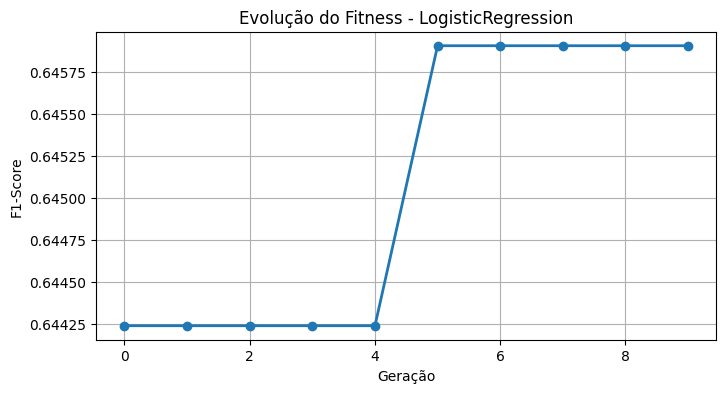

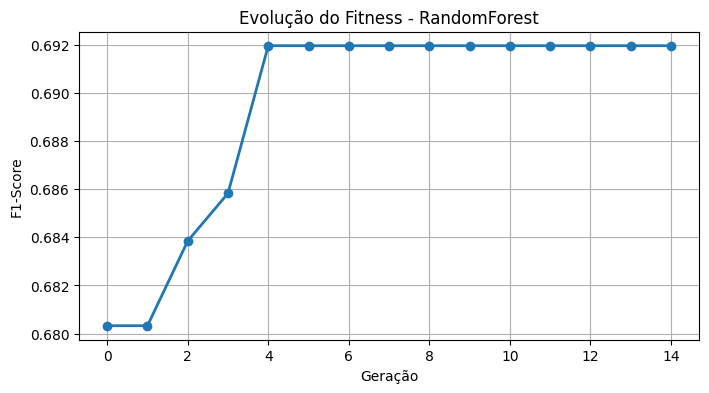

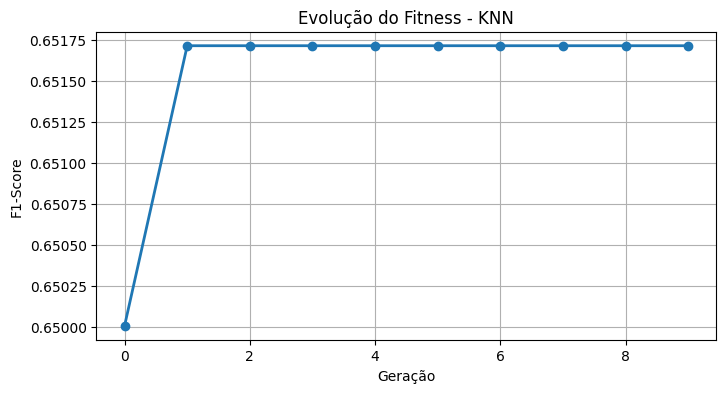

In [49]:
# ==========================================================
# EVOLUÇÃO DO FITNESS
# ==========================================================

import matplotlib.pyplot as plt

for nome_modelo, resultado in melhores_resultados.items():

    plt.figure(figsize=(8, 4))

    plt.plot(
        resultado["historico"],
        marker="o",
        linewidth=2
    )

    plt.title(f"Evolução do Fitness - {nome_modelo}")

    plt.xlabel("Geração")

    plt.ylabel("F1-Score")

    plt.grid(True)

    plt.show()

Explicação

Esse gráfico utiliza a lista historico, preenchida dentro da função algoritmo_genetico(). Assim, conseguimos acompanhar a evolução do melhor indivíduo encontrado até aquele momento.

## Resumo dos Experimentos

Para cada modelo de classificação foram executados três experimentos utilizando diferentes configurações do Algoritmo Genético.

A tabela a seguir apresenta:

- experimento executado;
- configuração utilizada;
- melhor valor da função de fitness (F1-Score);
- melhores hiperparâmetros encontrados.

Essas informações permitem analisar o impacto das diferentes configurações do Algoritmo Genético no processo de otimização.

In [50]:
# ==========================================================
# TABELA RESUMO DOS EXPERIMENTOS
# ==========================================================

resumo_experimentos = []

for nome_experimento, modelos in resultados_experimentos.items():

    for nome_modelo, resultado in modelos.items():

        resumo_experimentos.append({

            "Experimento": nome_experimento,

            "Modelo": nome_modelo,

            "População": resultado["config"]["population_size"],

            "Gerações": resultado["config"]["generations"],

            "Taxa de Mutação": resultado["config"]["mutation_rate"],

            "Melhor F1": round(resultado["melhor_fitness"], 4),

            "Melhores Hiperparâmetros": str(resultado["melhor_individuo"])

        })

df_experimentos = pd.DataFrame(resumo_experimentos)

df_experimentos

,Experimento,Modelo,População,Gerações,Taxa de Mutação,Melhor F1,Melhores Hiperparâmetros
0,Experimento 1,LogisticRegression,20,10,0.10,0.6459,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': ..."
1,Experimento 1,RandomForest,20,10,0.10,0.6833,"{'n_estimators': 78, 'max_depth': 10, 'min_sam..."
2,Experimento 1,KNN,20,10,0.10,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"
3,Experimento 2,LogisticRegression,30,15,0.15,0.6459,"{'C': 0.982, 'solver': 'liblinear', 'max_iter'..."
4,Experimento 2,RandomForest,30,15,0.15,0.6920,"{'n_estimators': 62, 'max_depth': 15, 'min_sam..."
5,Experimento 2,KNN,30,15,0.15,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"
6,Experimento 3,LogisticRegression,40,20,0.20,0.6459,"{'C': 1.106, 'solver': 'liblinear', 'max_iter'..."
7,Experimento 3,RandomForest,40,20,0.20,0.6871,"{'n_estimators': 102, 'max_depth': 15, 'min_sa..."
8,Experimento 3,KNN,40,20,0.20,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"


In [51]:
# ==========================================================
# TABELA ORDENADA PELO MELHOR F1
# ==========================================================

df_experimentos.sort_values(
    by=["Modelo", "Melhor F1"],
    ascending=[True, False]
)

,Experimento,Modelo,População,Gerações,Taxa de Mutação,Melhor F1,Melhores Hiperparâmetros
2,Experimento 1,KNN,20,10,0.10,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"
5,Experimento 2,KNN,30,15,0.15,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"
8,Experimento 3,KNN,40,20,0.20,0.6517,"{'n_neighbors': 9, 'weights': 'distance'}"
0,Experimento 1,LogisticRegression,20,10,0.10,0.6459,"{'C': 1.0, 'solver': 'liblinear', 'max_iter': ..."
3,Experimento 2,LogisticRegression,30,15,0.15,0.6459,"{'C': 0.982, 'solver': 'liblinear', 'max_iter'..."
6,Experimento 3,LogisticRegression,40,20,0.20,0.6459,"{'C': 1.106, 'solver': 'liblinear', 'max_iter'..."
4,Experimento 2,RandomForest,30,15,0.15,0.6920,"{'n_estimators': 62, 'max_depth': 15, 'min_sam..."
7,Experimento 3,RandomForest,40,20,0.20,0.6871,"{'n_estimators': 102, 'max_depth': 15, 'min_sa..."
1,Experimento 1,RandomForest,20,10,0.10,0.6833,"{'n_estimators': 78, 'max_depth': 10, 'min_sam..."


In [52]:
# ==========================================================
# MELHOR EXPERIMENTO POR MODELO
# ==========================================================

df_melhores = pd.DataFrame([
    {
        "Modelo": modelo,
        "Experimento Selecionado": resultado["experimento"],
        "Melhor F1": round(resultado["melhor_fitness"], 4)
    }

    for modelo, resultado in melhores_resultados.items()
])

df_melhores

,Modelo,Experimento Selecionado,Melhor F1
0,LogisticRegression,Experimento 1,0.6459
1,RandomForest,Experimento 2,0.6920
2,KNN,Experimento 1,0.6517


## Ganho Obtido com a Otimização

Para facilitar a interpretação dos resultados, foi calculada a variação do F1-Score entre o Modelo Original (Fase 1) e o Modelo Otimizado (Fase 2).

O ganho percentual permite avaliar, de forma objetiva, o impacto da otimização dos hiperparâmetros realizada pelo Algoritmo Genético.

In [53]:
# ==========================================================
# GANHO OBTIDO COM A OTIMIZAÇÃO
# ==========================================================

comparativo_final = []

for modelo in df_comparacao["Modelo"].unique():

    original = df_comparacao[
        (df_comparacao["Modelo"] == modelo) &
        (df_comparacao["Tipo"] == "Modelo Original (Fase 1)")
    ].iloc[0]

    otimizado = df_comparacao[
        (df_comparacao["Modelo"] == modelo) &
        (df_comparacao["Tipo"] == "Modelo Otimizado (Fase 2)")
    ].iloc[0]

    ganho = (
        (otimizado["F1-Score"] - original["F1-Score"])
        / original["F1-Score"]
    ) * 100

    comparativo_final.append({

        "Modelo": modelo,

        "F1 Original": round(original["F1-Score"], 4),

        "F1 Otimizado": round(otimizado["F1-Score"], 4),

        "Ganho (%)": round(ganho, 2)

    })

df_ganho = pd.DataFrame(comparativo_final)

df_ganho

,Modelo,F1 Original,F1 Otimizado,Ganho (%)
0,LogisticRegression,0.5918,0.5918,0.00
1,RandomForest,0.6471,0.6214,-3.97
2,KNN,0.5607,0.5825,3.88


In [54]:
# ==========================================================
# MODELOS COM MAIOR GANHO
# ==========================================================

df_ganho.sort_values(
    by="Ganho (%)",
    ascending=False
)

,Modelo,F1 Original,F1 Otimizado,Ganho (%)
2,KNN,0.5607,0.5825,3.88
0,LogisticRegression,0.5918,0.5918,0.00
1,RandomForest,0.6471,0.6214,-3.97


Explicação

Essa tabela resume o impacto da otimização realizada pelo Algoritmo Genético. Para cada modelo, é apresentada a comparação entre o desempenho obtido com os hiperparâmetros originais da Fase 1 e o desempenho alcançado após a otimização dos hiperparâmetros na Fase 2.

O ganho percentual foi calculado com base no F1-Score, métrica adotada como função de fitness durante a execução do Algoritmo Genético, permitindo quantificar objetivamente a melhoria obtida.

In [55]:
# ==========================================================
# COMPARAÇÃO CONSOLIDADA
# ==========================================================

comparacao_consolidada = []

for modelo in df_comparacao["Modelo"].unique():

    original = df_comparacao[
        (df_comparacao["Modelo"] == modelo) &
        (df_comparacao["Tipo"] == "Modelo Original (Fase 1)")
    ].iloc[0]

    otimizado = df_comparacao[
        (df_comparacao["Modelo"] == modelo) &
        (df_comparacao["Tipo"] == "Modelo Otimizado (Fase 2)")
    ].iloc[0]

    comparacao_consolidada.append({

        "Modelo": modelo,

        "Accuracy Original": round(original["Accuracy"],4),
        "Accuracy Otimizado": round(otimizado["Accuracy"],4),

        "Precision Original": round(original["Precision"],4),
        "Precision Otimizado": round(otimizado["Precision"],4),

        "Recall Original": round(original["Recall"],4),
        "Recall Otimizado": round(otimizado["Recall"],4),

        "F1 Original": round(original["F1-Score"],4),
        "F1 Otimizado": round(otimizado["F1-Score"],4)

    })

df_final = pd.DataFrame(comparacao_consolidada)

df_final

,Modelo,Accuracy Original,Accuracy Otimizado,Precision Original,Precision Otimizado,Recall Original,Recall Otimizado,F1 Original,F1 Otimizado
0,LogisticRegression,0.7436,0.7436,0.5577,0.5577,0.6304,0.6304,0.5918,0.5918
1,RandomForest,0.7692,0.7500,0.5893,0.5614,0.7174,0.6957,0.6471,0.6214
2,KNN,0.6987,0.7244,0.4918,0.5263,0.6522,0.6522,0.5607,0.5825


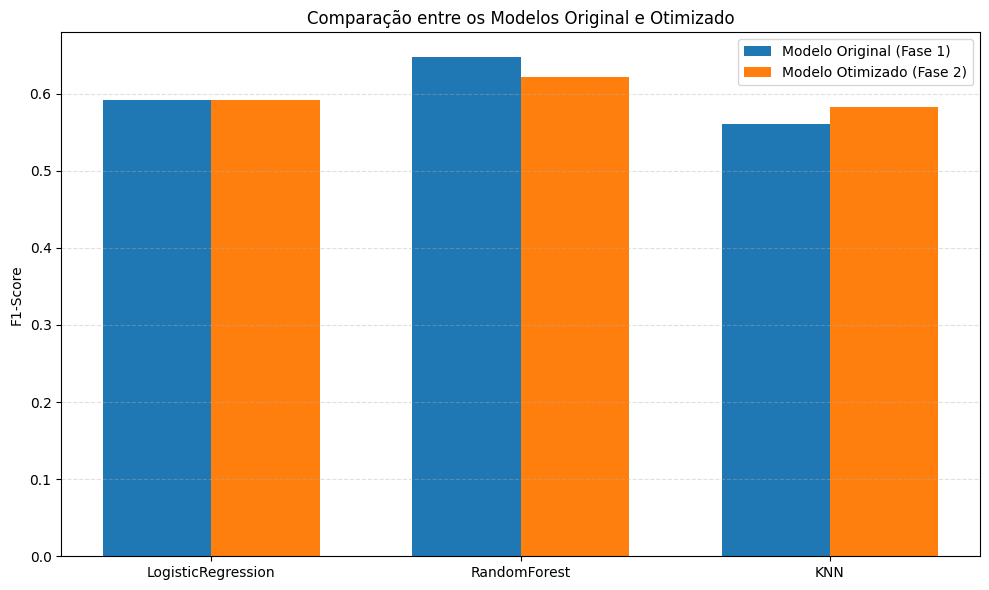

In [56]:
# ==========================================================
# COMPARAÇÃO DO F1-SCORE
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Dados
modelos = df_final["Modelo"]

f1_original = df_final["F1 Original"]

f1_otimizado = df_final["F1 Otimizado"]

# Posição das barras
x = np.arange(len(modelos))
largura = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - largura/2,
    f1_original,
    largura,
    label="Modelo Original (Fase 1)"
)

plt.bar(
    x + largura/2,
    f1_otimizado,
    largura,
    label="Modelo Otimizado (Fase 2)"
)

plt.xticks(x, modelos)

plt.ylabel("F1-Score")

plt.title("Comparação entre os Modelos Original e Otimizado")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# 3. Integração com LLMs para Interpretação de Resultados

**Objetivo:** integrar uma LLM pré-treinada ao pipeline para:

- Gerar explicações em **linguagem natural** dos diagnósticos/resultados produzidos pelos modelos;
- Transformar dados numéricos e estatísticos (F1-Score, ganho %, hiperparâmetros) em
  **metricas** para profissionais de saúde;
- Gerar interpretações **paciente a paciente**, preparando a base para a futura integração
  com dados textuais (prontuários, anotações clínicas);



In [ ]:
# ==========================================================
# CONFIGURAÇÃO DA LLM -- AZURE AI FOUNDRY (com fallback em modo simulado)
# ==========================================================

!pip install -q azure-ai-inference azure-core

import os
import re
import json
from getpass import getpass

AZURE_FOUNDRY_RESOURCE = "appfinanceduran-foundry"
AZURE_FOUNDRY_ENDPOINT = f"https://{AZURE_FOUNDRY_RESOURCE}.services.ai.azure.com/models"
AZURE_FOUNDRY_API_VERSION = "2024-05-01-preview"  # ajuste se o portal indicar outra versão
AZURE_FOUNDRY_DEPLOYMENT = "gpt-5-mini"  # nome do deployment no Foundry

if "AZURE_AI_API_KEY" not in os.environ or not os.environ.get("AZURE_AI_API_KEY"):
    chave_informada = getpass(
        "Chave de API do Foundry"
    )
    if chave_informada:
        os.environ["AZURE_AI_API_KEY"] = chave_informada

USE_LLM_REAL = bool(os.environ.get("AZURE_AI_API_KEY"))

if USE_LLM_REAL:
    from azure.ai.inference import ChatCompletionsClient
    from azure.ai.inference.models import SystemMessage, UserMessage
    from azure.core.credentials import AzureKeyCredential

    azure_client = ChatCompletionsClient(
        endpoint=AZURE_FOUNDRY_ENDPOINT,
        credential=AzureKeyCredential(os.environ["AZURE_AI_API_KEY"]),
        api_version=AZURE_FOUNDRY_API_VERSION,
    )
    print(f"Modo REAL ativado -> Azure AI Foundry, deployment '{AZURE_FOUNDRY_DEPLOYMENT}'.")
else:
    print("nenhuma chave foi informada.")

In [ ]:
# ==========================================================
# SYSTEM PROMPT (role prompting + guardrails) E FUNÇÃO DE CHAMADA
# ==========================================================

SYSTEM_PROMPT = """Você é um assistente de apoio à decisão clínica, especializado em interpretar
resultados de modelos de Machine Learning aplicados à triagem de diabetes em um hospital
universitário.

Regras obrigatórias:
1. Use linguagem clara, objetiva e acessível para médicos e enfermeiros, sem jargão de ML.
2. Nunca afirme um diagnóstico definitivo. Trate sempre o resultado do modelo como um indicador
   de risco que deve ser validado clinicamente por um profissional de saúde.
3. Traduza métricas estatísticas (accuracy, precision, recall, F1-score) em impacto prático
   (ex.: quantos pacientes de risco o modelo pode deixar de identificar).
4. Estruture a resposta em tópicos curtos, com no máximo 150 palavras.
5. Finalize sempre com uma recomendação prática e objetiva para a equipe médica.
"""


def _simular_resposta_llm(prompt_usuario):
    """
    Gera uma resposta simulada (sem chamada real à LLM), extraindo os pares
    'rótulo: valor' presentes no prompt para produzir um texto minimamente coerente.
    Usada apenas quando nenhuma chave de API é configurada (modo SIMULADO).
    """
    pares = re.findall(r"[A-Za-zÀ-ú][A-Za-zÀ-ú \-\_/]+:\s*-?\d+\.?\d*%?", prompt_usuario)
    pontos = "\n".join(f"- {p.strip()}" for p in pares[:6]) or "- (nenhum dado numérico identificado no prompt)"

    return (
        "[RESPOSTA SIMULADA -- configure AZURE_AI_API_KEY para obter uma interpretação real da LLM]\n\n"
        "Principais indicadores identificados no contexto enviado:\n"
        f"{pontos}\n\n"
        "Recomendação: revisar os indicadores acima em conjunto com a equipe médica antes de "
        "qualquer decisão clínica. Configure uma chave de API válida para obter uma interpretação "
        "completa gerada por linguagem natural."
    )


def _extrair_texto_e_diagnostico(resposta):
    """
    Extrai o texto da resposta e monta uma string de diagnóstico (finish_reason +
    uso de tokens, quando disponível) para ajudar a depurar respostas vazias.
    """
    texto = (resposta.choices[0].message.content or "").strip()
    finish_reason = getattr(resposta.choices[0], "finish_reason", "desconhecido")
    uso = getattr(resposta, "usage", None)
    diagnostico = f"finish_reason={finish_reason}"
    if uso is not None:
        diagnostico += f" | usage={uso}"
    return texto, diagnostico


def chamar_llm(prompt_usuario, temperature=0.3, max_tokens=400, debug=False):
    """
    Envia um prompt (com o system prompt de apoio clínico) para o modelo configurado
    no Azure AI Foundry e retorna a resposta em texto.

    'gpt-5-mini' é um modelo de RACIOCÍNIO: parte do orçamento de tokens é consumida
    internamente em raciocínio invisível, contado dentro de 'max_completion_tokens'.
    Se o orçamento for pequeno, o conteúdo visível pode vir vazio mesmo sem erro
    (finish_reason='length'). Por isso:
      1) tentamos primeiro no formato clássico (max_tokens + temperature);
      2) se vier vazio/erro, tentamos via model_extras com orçamentos crescentes;
      3) por fim, tentamos reduzir o esforço de raciocínio (reasoning_effort), se o
         deployment aceitar esse parâmetro extra.

    Se debug=True, imprime o diagnóstico (finish_reason/usage) de cada tentativa.

    Se nenhuma chave de API estiver configurada, cai automaticamente no modo simulado.
    """
    if not USE_LLM_REAL:
        return _simular_resposta_llm(prompt_usuario)

    mensagens = [
        SystemMessage(content=SYSTEM_PROMPT),
        UserMessage(content=prompt_usuario),
    ]

    ultimo_erro = None
    diagnosticos = []


    try:
        resposta = azure_client.complete(
            model=AZURE_FOUNDRY_DEPLOYMENT,
            messages=mensagens,
            temperature=temperature,
            max_tokens=max_tokens,
        )
        texto, diag = _extrair_texto_e_diagnostico(resposta)
        diagnosticos.append(f"[classico max_tokens={max_tokens}] {diag}")
        if texto:
            return texto
    except Exception as erro:
        ultimo_erro = erro
        diagnosticos.append(f"[classico max_tokens={max_tokens}] erro: {erro}")


    for orcamento in (max(max_tokens, 800) * 3, 3000, 6000):
        try:
            resposta = azure_client.complete(
                model=AZURE_FOUNDRY_DEPLOYMENT,
                messages=mensagens,
                model_extras={"max_completion_tokens": orcamento},
            )
            texto, diag = _extrair_texto_e_diagnostico(resposta)
            diagnosticos.append(f"[model_extras max_completion_tokens={orcamento}] {diag}")
            if texto:
                return texto
        except Exception as erro:
            ultimo_erro = erro
            diagnosticos.append(f"[model_extras max_completion_tokens={orcamento}] erro: {erro}")
            continue


    for esforco in ("low", "minimal"):
        try:
            resposta = azure_client.complete(
                model=AZURE_FOUNDRY_DEPLOYMENT,
                messages=mensagens,
                model_extras={"max_completion_tokens": 3000, "reasoning_effort": esforco},
            )
            texto, diag = _extrair_texto_e_diagnostico(resposta)
            diagnosticos.append(f"[reasoning_effort={esforco}] {diag}")
            if texto:
                return texto
        except Exception as erro:
            ultimo_erro = erro
            diagnosticos.append(f"[reasoning_effort={esforco}] erro: {erro}")
            continue

    if debug:
        print("\n".join(diagnosticos))

    raise RuntimeError(
        f"O modelo '{AZURE_FOUNDRY_DEPLOYMENT}' não retornou conteúdo em nenhuma tentativa.\n"
        f"Diagnóstico das tentativas:\n" + "\n".join(diagnosticos) +
        (f"\n\nÚltimo erro (se houve): {ultimo_erro}" if ultimo_erro else "")
    )


### 3.2 Explicações Individuais de Diagnóstico por Paciente

Aqui a integração é levada ao nível do **paciente individual**: para cada caso do conjunto de
teste, os dados clínicos (Glicose, IMC, Idade, etc.) e a predição do modelo otimizado são
enviados à LLM, que gera uma explicação em linguagem natural do resultado.

Essa função (`gerar_explicacao_diagnostico`) é a base reutilizável que será estendida no
**Módulo 3** para também considerar dados textuais (ex.: anotações de prontuário, histórico
relatado pelo paciente), bastando adicionar esses campos ao dicionário de entrada do prompt.

In [60]:
# ==========================================================
# TREINAMENTO DO MELHOR MODELO OTIMIZADO (PARA GERAR PREDIÇÕES POR PACIENTE)
# ==========================================================

melhor_modelo_nome = df_final.loc[df_final["F1 Otimizado"].idxmax(), "Modelo"]
print(f"Modelo selecionado para explicações individuais: {melhor_modelo_nome}")

modelo_otimizado_final = construir_modelo(
    melhor_modelo_nome,
    melhores_resultados[melhor_modelo_nome]["melhor_individuo"]
)

modelo_otimizado_final.fit(X_train, y_train)

y_pred_final = modelo_otimizado_final.predict(X_test)
y_proba_final = modelo_otimizado_final.predict_proba(X_test)[:, 1]



Modelo selecionado para explicações individuais: RandomForest


In [ ]:
# ==========================================================
# FUNÇÃO GENÉRICA DE PROMPT
# ==========================================================

def montar_prompt_paciente_customizado(dados_paciente, predicao, probabilidade):
    """
    Monta o prompt de explicação individual a partir de um dicionário de dados
    clínicos (em vez de um índice de X_test), permitindo reutilizar a mesma
    lógica tanto para os pacientes de teste quanto para pacientes digitados
    manualmente na Área de Teste Interativa.
    """
    dados_clinicos = "\n".join(f"- {coluna}: {valor}" for coluna, valor in dados_paciente.items())

    prompt = f"""
Paciente com os seguintes dados clínicos:
{dados_clinicos}

Resultado do modelo "{melhor_modelo_nome}" (otimizado por Algoritmo Genético):
- Classificação: {"Risco de diabetes" if predicao == 1 else "Sem indício de diabetes"}
- Probabilidade estimada de diabetes: {probabilidade:.1%}

Gere uma explicação em linguagem natural desse resultado para a equipe médica, destacando
quais fatores clínicos acima mais provavelmente influenciaram essa predição.
"""
    return prompt.strip()


In [ ]:
# ==========================================================
# PROMPT: EXPLICAÇÃO DE DIAGNÓSTICO INDIVIDUAL 
# ==========================================================

def montar_prompt_paciente(indice_paciente):
    """
    Monta o prompt de explicação individual para um paciente do conjunto de teste,
    injetando seus dados clínicos e a predição do modelo otimizado.
    """
    paciente = X_test.iloc[indice_paciente]
    predicao = int(y_pred_final[indice_paciente])
    probabilidade = float(y_proba_final[indice_paciente])
    return montar_prompt_paciente_customizado(paciente.to_dict(), predicao, probabilidade)


def gerar_explicacao_diagnostico(indice_paciente):
    """
    Função reutilizável: gera a explicação em linguagem natural para um paciente
    do conjunto de teste. Serve como base para a integração futura com dados
    textuais (Módulo 3) -- basta enriquecer o prompt com os novos campos.
    """
    prompt = montar_prompt_paciente(indice_paciente)
    return chamar_llm(prompt, max_tokens=300)


# ==========================================================
# REGISTRO CENTRAL DAS EXPLICAÇÕES GERADAS 
# ==========================================================

explicacoes_pacientes = {}

# Gera explicações para os 3 primeiros pacientes do conjunto de teste
for indice_paciente in range(3):
    paciente = X_test.iloc[indice_paciente]
    predicao = int(y_pred_final[indice_paciente])
    probabilidade = float(y_proba_final[indice_paciente])

    texto = gerar_explicacao_diagnostico(indice_paciente)
    chave = f"X_test #{indice_paciente}"

    explicacoes_pacientes[chave] = {
        "texto": texto,
        "contexto": {**paciente.to_dict(), "predicao": predicao, "probabilidade": probabilidade},
    }

    print("=" * 70)
    print(chave)
    print("=" * 70)
    print(texto)
    print()


X_test #0
- Resumo: o modelo classificou o paciente como "risco de diabetes" com probabilidade estimada de 53,9% — é um indicador de risco, não um diagnóstico definitivo.

- Fatores que mais provavelmente impulsionaram a predição: glicemia em 188 mg/dL (contribuição principal), IMC 32 kg/m2 (obesidade, risco aumentado), insulina 185 µU/mL (sugere resistência insulínica), DPF 0,682 (história familiar/ predisposição). Idade 22 anos tende a reduzir risco pré-teste; pressão arterial 82 mmHg e espessura cutânea 14 mm tiveram menor influência.

- Incerteza do modelo: sem métricas do modelo aqui, não é possível quantificar erros. Para interpretar impacto prático, exemplo: se a sensibilidade fosse 80%, o modelo deixaria de identificar 20 em cada 100 casos reais; se o valor preditivo positivo fosse 60%, 40 em cada 100 classificados como risco seriam falsos positivos.

- Ações clínicas imediatas recomendadas: confirmar com exames laboratoriais (glicemia de jejum, HbA1c; considerar TTO), avaliar 

### 3.2.1 Área de Teste Interativa (Simulador de Diagnóstico + Explicação da LLM)

Além dos pacientes de exemplo do conjunto de teste, esta área permite **digitar os dados de
um paciente manualmente**: o melhor modelo otimizado (`modelo_otimizado_final`) é reutilizado
para gerar a predição, e o resultado é automaticamente enviado à LLM para gerar uma explicação
em linguagem natural -- que também é adicionada a `explicacoes_pacientes`.


In [63]:
# ==========================================================
# ÁREA DE TESTE INTERATIVA -- SIMULADOR DE DIAGNÓSTICO + EXPLICAÇÃO DA LLM
# ==========================================================

def executar_app_predicao():
    """
    Área de teste interativa: coleta os dados de um paciente digitados manualmente,
    executa o melhor modelo otimizado (Fase 2) já treinado (modelo_otimizado_final)
    e gera uma explicação em linguagem natural do resultado via LLM.

    O resultado (texto da explicação + dados usados) é adicionado ao dicionário
    'explicacoes_pacientes', para ser incluído automaticamente na avaliação de
    qualidade da seção 3.3, junto com os pacientes do conjunto de teste.
    """
    print("=== Aplicativo de Diagnóstico de Diabetes ===")
    print(f"Modelo em uso: {melhor_modelo_nome} (Otimizado)")
    print(f"Hiperparâmetros: {melhores_resultados[melhor_modelo_nome]['melhor_individuo']}\n")

    print("Por favor, insira os dados do paciente para realizar a predição:")

    try:
        dados_paciente = {
            "Pregnancies": int(input("Número de Gestações: ")),
            "Glucose": float(input("Glicose: ")),
            "BloodPressure": float(input("Pressão Arterial: ")),
            "SkinThickness": float(input("Espessura da Pele: ")),
            "Insulin": float(input("Insulina: ")),
            "IMC": float(input("IMC (ex: 25.5): ")),
            "DPF": float(input("Diabetes Pedigree Function (ex: 0.5): ")),
            "Age": int(input("Idade: ")),
        }
    except ValueError:
        print("\nErro: Certifique-se de inserir apenas valores numéricos válidos.")
        return None

    df_paciente = pd.DataFrame([dados_paciente])

    predicao = int(modelo_otimizado_final.predict(df_paciente)[0])
    probabilidade = float(modelo_otimizado_final.predict_proba(df_paciente)[0][1])

    print("\n" + "=" * 40)
    print("RESULTADO DO DIAGNÓSTICO:")
    print("Sinaliza: POSITIVO para Diabetes" if predicao == 1 else "Sinaliza: NEGATIVO para Diabetes")
    print(f"Confiança do modelo: {probabilidade:.2%}")
    print("=" * 40)

    print("\nGerando explicação da LLM para este resultado...\n")

    prompt = montar_prompt_paciente_customizado(dados_paciente, predicao, probabilidade)
    explicacao = chamar_llm(prompt, max_tokens=300)

    print("-" * 40)
    print("EXPLICAÇÃO GERADA PELA LLM:")
    print("-" * 40)
    print(explicacao)

    # Registra o resultado -- entra automaticamente na avaliação de qualidade (3.3)
    numero_teste = len([k for k in explicacoes_pacientes if str(k).startswith("Teste manual")]) + 1
    chave = f"Teste manual #{numero_teste}"

    explicacoes_pacientes[chave] = {
        "texto": explicacao,
        "contexto": {**dados_paciente, "predicao": predicao, "probabilidade": probabilidade},
    }

    return {
        "dados_paciente": dados_paciente,
        "predicao": predicao,
        "probabilidade": probabilidade,
        "explicacao": explicacao,
    }


# Executa a área de teste (pode ser rodada quantas vezes quiser, um paciente por vez)
resultado_teste_manual = executar_app_predicao()


=== Aplicativo de Diagnóstico de Diabetes ===
Modelo em uso: RandomForest (Otimizado)
Hiperparâmetros: {'n_estimators': 62, 'max_depth': 15, 'min_samples_split': 4}

Por favor, insira os dados do paciente para realizar a predição:
Número de Gestações: 1
Glicose: 180
Pressão Arterial: 70
Espessura da Pele: 35
Insulina: 94
IMC (ex: 25.5): 33
Diabetes Pedigree Function (ex: 0.5): 0.6
Idade: 40

RESULTADO DO DIAGNÓSTICO:
Sinaliza: POSITIVO para Diabetes
Confiança do modelo: 80.38%

Gerando explicação da LLM para este resultado...

----------------------------------------
EXPLICAÇÃO GERADA PELA LLM:
----------------------------------------
- Resultado: modelo RandomForest indica "Risco de diabetes" com probabilidade estimada 80,4% — indicador de alto risco, não diagnóstico definitivo.  
- Interpretação clínica: probabilidade alta sugere necessidade de investigação confirmatória e monitorização mais próxima.  
- Fatores que provavelmente mais influenciaram a predição (em ordem provável): gli